-->>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> **Retail-Sales-Analysis** <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<--



In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3


df = pd.read_excel("C:/Users/muskan yadav/OneDrive/文档/Desktop/Retail-Sales-Analysis/data/Online Retail.xlsx")


In [96]:
df.shape

(541909, 8)

In [97]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [98]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [99]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [100]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [101]:
df = df.head(8000)

In [102]:
df.shape

(8000, 8)

In [103]:
df.to_csv("../data/online_retail_sample.csv", index=False)

In [104]:
df = pd.read_csv(
    "../data/online_retail_sample.csv",
    parse_dates=["InvoiceDate"]
)

In [105]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description      42
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     2290
Country           0
dtype: int64

In [106]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [107]:
df.nunique()

InvoiceNo       444
StockCode      1897
Description    1857
Quantity        112
InvoiceDate     383
UnitPrice       148
CustomerID      277
Country          14
dtype: int64

In [108]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
7995,537081,21914,BLUE HARMONICA IN BOX,36,2010-12-05 12:00:00,1.25,15332.0,Lithuania
7996,537081,22273,FELTCRAFT DOLL MOLLY,12,2010-12-05 12:00:00,2.95,15332.0,Lithuania
7997,537081,22306,SILVER MUG BONE CHINA TREE OF LIFE,36,2010-12-05 12:00:00,1.65,15332.0,Lithuania
7998,537081,22307,GOLD MUG BONE CHINA TREE OF LIFE,36,2010-12-05 12:00:00,1.65,15332.0,Lithuania
7999,537081,22300,COFFEE MUG DOG + BALL DESIGN,18,2010-12-05 12:00:00,2.55,15332.0,Lithuania


In [109]:
df.duplicated().sum()

np.int64(114)

In [110]:
#Remove duplicate rows
df = df.drop_duplicates()

In [111]:
df.duplicated().sum()

np.int64(0)

In [112]:
#Check Missing Descriptions
df[df["Description"].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [113]:
#Check Missing Customer IDs

df[df["CustomerID"].isnull()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


In [114]:
#This removes only rows where CustomerID is missing, keeping rows with other valid information.
df = df.dropna(subset=["CustomerID"])

In [115]:
df.shape

(5596, 8)

In [116]:
#Negative Quantities
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
7437,C537039,22854,CREAM SWEETHEART EGG HOLDER,-1,2010-12-05 10:25:00,4.95,15708.0,United Kingdom
7438,C537039,20936,FORKED CACTUS CANDLE,-1,2010-12-05 10:25:00,2.95,15708.0,United Kingdom
7439,C537039,85175,CACTI T-LIGHT CANDLES,-1,2010-12-05 10:25:00,0.42,15708.0,United Kingdom
7520,C537043,22575,METAL MERRY CHRISTMAS WREATH,-6,2010-12-05 10:48:00,1.95,15351.0,United Kingdom


In [117]:
#Zero or Negative Prices
df[df["UnitPrice"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


-->>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> **Data cleaning** <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<--



In [119]:
df = df.drop_duplicates()

df[df["Description"].isnull()]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [120]:
df[df["CustomerID"].isnull()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [121]:
df = df.dropna(subset=["CustomerID"])
df.shape

(5596, 8)

In [122]:
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
7437,C537039,22854,CREAM SWEETHEART EGG HOLDER,-1,2010-12-05 10:25:00,4.95,15708.0,United Kingdom
7438,C537039,20936,FORKED CACTUS CANDLE,-1,2010-12-05 10:25:00,2.95,15708.0,United Kingdom
7439,C537039,85175,CACTI T-LIGHT CANDLES,-1,2010-12-05 10:25:00,0.42,15708.0,United Kingdom
7520,C537043,22575,METAL MERRY CHRISTMAS WREATH,-6,2010-12-05 10:48:00,1.95,15351.0,United Kingdom


In [123]:
df[df["UnitPrice"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [124]:
#Remove Negative Quantity
df = df[df["Quantity"] > 0]

In [125]:
df.shape

(5507, 8)

In [126]:
df.to_csv("../data/cleaned_online_retail.csv", index=False)

In [127]:
###################### Feature Engineering ########################

In [128]:
#Create Revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [129]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [130]:
#Extract the Year
df["Order_Year"] = df["InvoiceDate"].dt.year

In [131]:
#Extract Month Name
df["Order_Month"] = df["InvoiceDate"].dt.month_name()

In [132]:
#Extract Month Number
df["Month_Number"] = df["InvoiceDate"].dt.month

In [133]:
#Extract Day Name
df["Order_Day"] = df["InvoiceDate"].dt.day_name()

In [134]:
#Extract Hour
df["Order_Hour"] = df["InvoiceDate"].dt.hour

In [135]:
#Weekend or Not?
df["Is_Weekend"] = df["Order_Day"].isin(["Saturday", "Sunday"])

In [136]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Order_Year,Order_Month,Month_Number,Order_Day,Order_Hour,Is_Weekend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,December,12,Wednesday,8,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,12,Wednesday,8,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,December,12,Wednesday,8,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,12,Wednesday,8,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,12,Wednesday,8,False


In [137]:
#Save the Feature-Engineered Dataset
df.to_csv("../data/final_retail_data.csv", index=False)

-->>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> **Exploratory Data Analysis (EDA)** <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<--

In [139]:
# Q1:what is the total revenue

total_revenue = df["Revenue"].sum()

print(f"Total Revenue: £{total_revenue:.2f}")

Total Revenue: £125821.02


In [140]:
# Q2:Total Orders

total_orders = df["InvoiceNo"].nunique()

print("Total Orders:", total_orders)

Total Orders: 339


In [141]:
# Q3:Unique Customers

total_customers = df["CustomerID"].nunique()

print("Unique Customers:", total_customers)

Unique Customers: 256


In [142]:
# Q4:Total Products Sold

total_products = df["Quantity"].sum()

print("Products Sold:", total_products)

Products Sold: 70518


In [143]:
# Q5:Average Product Price

average_price = df["UnitPrice"].mean()

print(f"Average Price: £{average_price:.2f}")

Average Price: £3.23


In [144]:
#Business Summary

print("="*40)
print(" Retail Sales Summary ")
print("="*40)

print(f"Total Revenue      : £{total_revenue:.2f}")
print(f"Total Orders       : {total_orders}")
print(f"Unique Customers   : {total_customers}")
print(f"Products Sold      : {total_products}")
print(f"Average Unit Price : £{average_price:.2f}")

 Retail Sales Summary 
Total Revenue      : £125821.02
Total Orders       : 339
Unique Customers   : 256
Products Sold      : 70518
Average Unit Price : £3.23


-->>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>  **Business Questions**  <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<--


In [146]:
# Q1 Top 10 Products by Revenue

top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
REGENCY CAKESTAND 3 TIER              4993.65
RED WOOLLY HOTTIE WHITE HEART.        2200.14
BLACK RECORD COVER FRAME              2078.43
WHITE HANGING HEART T-LIGHT HOLDER    2071.85
CHILLI LIGHTS                         1998.99
SET 7 BABUSHKA NESTING BOXES          1972.00
RED  HARMONICA IN BOX                 1724.00
PAPER CHAIN KIT 50'S CHRISTMAS        1246.70
PAPER CHAIN KIT VINTAGE CHRISTMAS     1223.10
ASSORTED COLOUR BIRD ORNAMENT         1219.43
Name: Revenue, dtype: float64

In [147]:
# Q2 Revenue by Country

country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_sales

Country
United Kingdom    114296.52
France              2808.16
EIRE                2605.73
Norway              1919.14
Germany              972.36
Spain                620.00
Lithuania            591.00
Italy                427.80
Australia            358.25
Belgium              346.10
Switzerland          303.40
Poland               248.16
Netherlands          192.60
Portugal             131.80
Name: Revenue, dtype: float64

In [148]:
# Q3 Top 10 Customers

top_customers = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

CustomerID
15061.0    9407.34
13777.0    6585.16
17850.0    5391.21
16029.0    4271.52
16210.0    2474.74
13081.0    2366.78
14911.0    2283.53
16754.0    2002.40
12433.0    1919.14
15299.0    1835.01
Name: Revenue, dtype: float64

In [149]:
# Q4 Most Sold Products (by Quantity)

most_sold_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

most_sold_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     3360
ASSORTED COLOUR T-LIGHT HOLDER        1824
RED  HARMONICA IN BOX                 1592
ASSORTED INCENSE PACK                 1440
PACK OF 72 RETROSPOT CAKE CASES        848
WHITE HANGING HEART T-LIGHT HOLDER     791
ASSORTED COLOUR BIRD ORNAMENT          767
PACK OF 12 LONDON TISSUES              713
RED WOOLLY HOTTIE WHITE HEART.         706
JUMBO BAG RED RETROSPOT                649
Name: Quantity, dtype: int64

In [150]:

print("\n Top 10 Products by Revenue")
print(top_products)

print("\n Revenue by Country")
print(country_sales)

print("\n Top 10 Customers")
print(top_customers)

print("\n Most Sold Products")
print(most_sold_products)


 Top 10 Products by Revenue
Description
REGENCY CAKESTAND 3 TIER              4993.65
RED WOOLLY HOTTIE WHITE HEART.        2200.14
BLACK RECORD COVER FRAME              2078.43
WHITE HANGING HEART T-LIGHT HOLDER    2071.85
CHILLI LIGHTS                         1998.99
SET 7 BABUSHKA NESTING BOXES          1972.00
RED  HARMONICA IN BOX                 1724.00
PAPER CHAIN KIT 50'S CHRISTMAS        1246.70
PAPER CHAIN KIT VINTAGE CHRISTMAS     1223.10
ASSORTED COLOUR BIRD ORNAMENT         1219.43
Name: Revenue, dtype: float64

 Revenue by Country
Country
United Kingdom    114296.52
France              2808.16
EIRE                2605.73
Norway              1919.14
Germany              972.36
Spain                620.00
Lithuania            591.00
Italy                427.80
Australia            358.25
Belgium              346.10
Switzerland          303.40
Poland               248.16
Netherlands          192.60
Portugal             131.80
Name: Revenue, dtype: float64

 Top 10 Customers

-->>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> **Visualization** <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<--

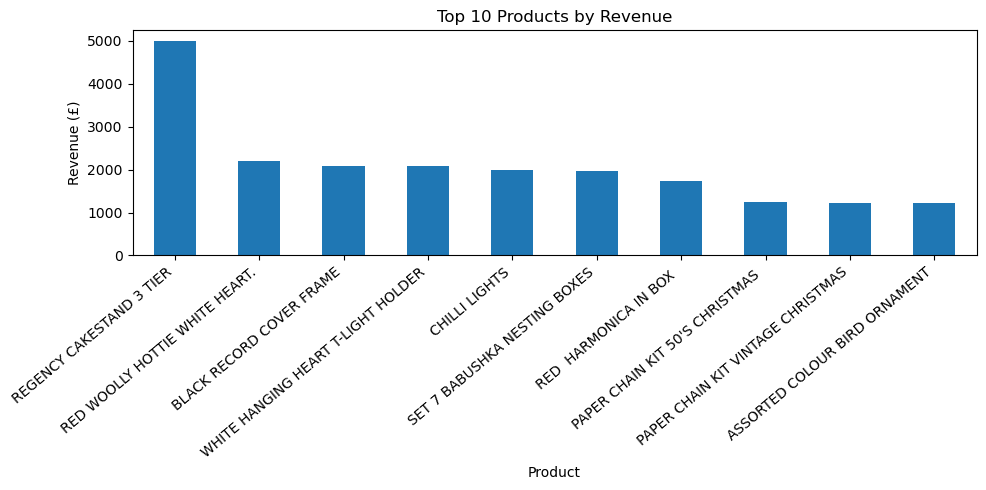

In [172]:
# 1: Top 10 Products by Revenue

top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=40, ha="right")

plt.tight_layout()

plt.savefig("../images/top_products_revenue.png")

plt.show()

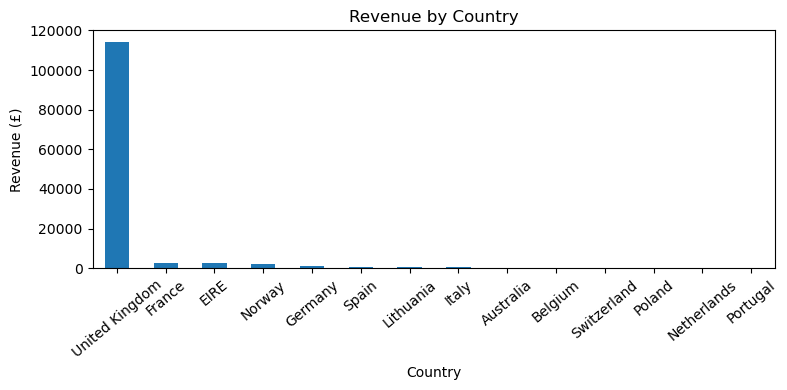

In [168]:
#2: Revenue by Country

country_sales.plot(kind="bar", figsize=(8,4))

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=40)

plt.tight_layout()

plt.savefig("../images/revenue_by_country.png")

plt.show()

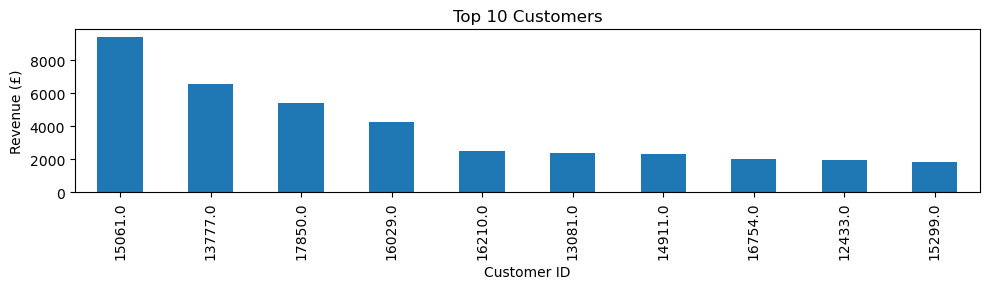

In [159]:
# 3: Top Customers

top_customers.plot(kind="bar", figsize=(10,3))

plt.title("Top 10 Customers")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")

plt.tight_layout()

plt.savefig("../images/top_customers.png")

plt.show()

In [156]:
# 4 Monthly Revenue Trend

monthly_sales = (
    df.groupby(["Month_Number", "Order_Month"])["Revenue"]
      .sum()
      .reset_index()
      .sort_values("Month_Number")
)

monthly_sales

,Month_Number,Order_Month,Revenue
0,12,December,125821.02


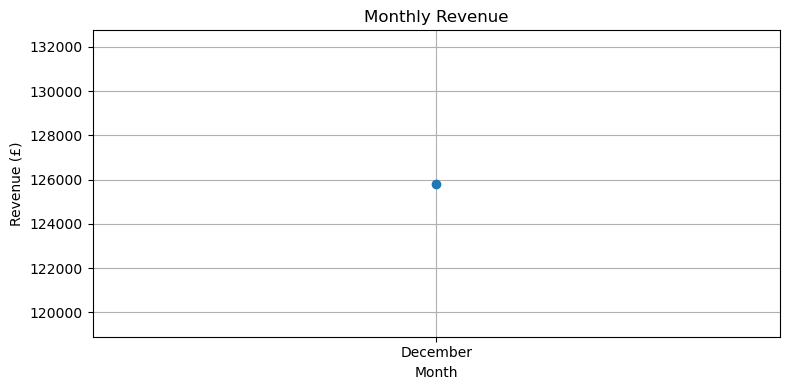

In [167]:
plt.figure(figsize=(8,4))

plt.plot(
    monthly_sales["Order_Month"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.grid(True)

plt.tight_layout()

plt.savefig("../images/monthly_revenue.png")

plt.show()

In [161]:
# Sales by Weekday

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
weekday_sales = (
    df.groupby("Order_Day")["Revenue"]
      .sum()
      .reindex(weekday_order)
)

weekday_sales

Order_Day
Monday            NaN
Tuesday           NaN
Wednesday    46192.49
Thursday     47197.57
Friday       23876.63
Saturday          NaN
Sunday        8554.33
Name: Revenue, dtype: float64

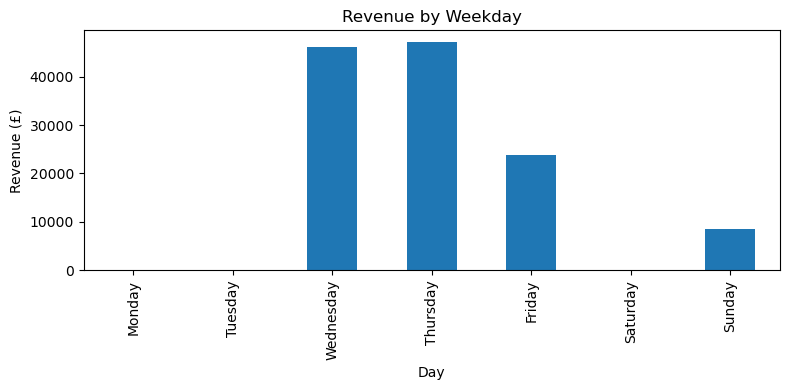

In [166]:
plt.figure(figsize=(8,4))

weekday_sales.plot(kind="bar")

plt.title("Revenue by Weekday")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")

plt.tight_layout()

plt.savefig("../images/weekday_sales.png")

plt.show()

In [173]:
#Peak Shopping Hours

hourly_sales = (
    df.groupby("Order_Hour")["Revenue"]
      .sum()
)

hourly_sales

Order_Hour
7       467.00
8      2300.74
9     11267.32
10    15571.38
11    13257.69
12    18919.94
13    11500.45
14     9739.41
15    17916.06
16    14551.30
17     7235.68
18     2564.50
19      529.55
Name: Revenue, dtype: float64

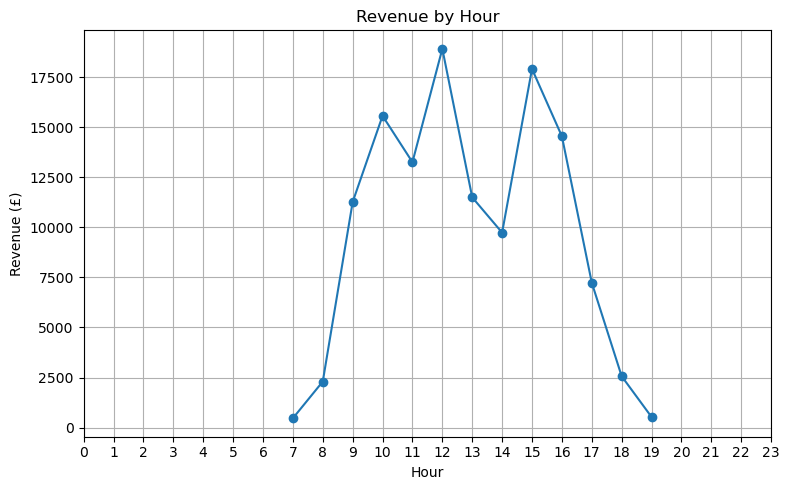

In [177]:
plt.figure(figsize=(8,5))

plt.plot(
    hourly_sales.index,
    hourly_sales.values,
    marker="o"
)

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue (£)")

plt.xticks(range(0,24))

plt.grid(True)

plt.tight_layout()

plt.savefig("../images/hourly_sales.png")

plt.show()

In [178]:
#Average Order Value (AOV)

average_order_value = total_revenue / total_orders

print(f"Average Order Value: £{average_order_value:.2f}")

Average Order Value: £371.15


In [180]:
#Repeat Customers

customer_orders = (
    df.groupby("CustomerID")["InvoiceNo"]
      .nunique()
)

repeat_customers = customer_orders[customer_orders > 1]

print("Repeat Customers:", repeat_customers.count())

Repeat Customers: 35


In [181]:
repeat_customers.sort_values(ascending=False).head(10)

CustomerID
17850.0    34
13777.0     7
15061.0     6
14911.0     4
16029.0     3
14849.0     3
15299.0     3
17809.0     3
13047.0     3
17581.0     2
Name: InvoiceNo, dtype: int64

In [182]:
#Largest Orders (Invoices)

top_invoices = (
    df.groupby("InvoiceNo")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_invoices


InvoiceNo
536783    4076.48
536387    3193.92
536785    2730.96
536576    2558.42
536477    2474.74
537034    2355.18
536784    2170.90
536830    2002.40
536532    1919.14
536390    1825.74
Name: Revenue, dtype: float64

-->>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> **NumPy Statistics** <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<--

In [183]:
#Revenue to a NumPy Array

revenue = df["Revenue"].to_numpy()

In [184]:
type(revenue)

numpy.ndarray

In [185]:
# mean
np.mean(revenue)

np.float64(22.847470492100964)

In [186]:
# median
np.median(revenue)

np.float64(12.600000000000001)

In [187]:
# maximum revenue
np.max(revenue)

np.float64(1627.2)

In [188]:
#Standard Deviation
np.std(revenue)

np.float64(62.66093282847906)

In [189]:
#Variance
np.var(revenue)

np.float64(3926.3925029351653)

In [192]:
#Percentiles
np.percentile(revenue, 25)

np.float64(19.9)

In [193]:
np.percentile(revenue, 50)

np.float64(12.600000000000001)

In [195]:
np.percentile(revenue, 75)

np.float64(19.9)

In [196]:
#Detect Outliers (IQR Method)

Q1 = np.percentile(revenue, 25)
Q3 = np.percentile(revenue, 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = revenue[
    (revenue < lower_bound) |
    (revenue > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 497


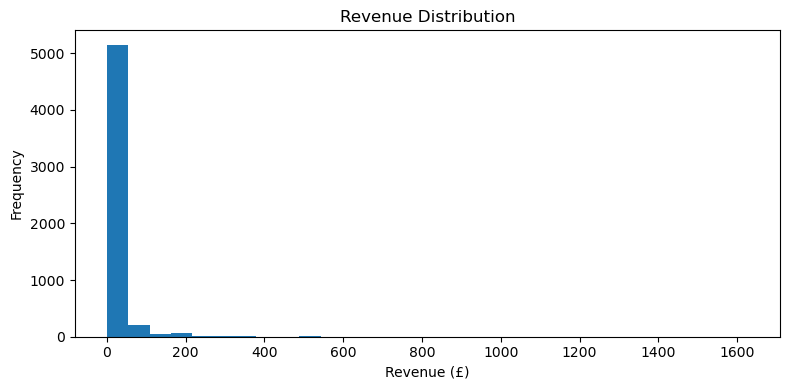

In [199]:
#Revenue Distribution (Histogram)

plt.figure(figsize=(8,4))

plt.hist(revenue, bins=30)

plt.title("Revenue Distribution")
plt.xlabel("Revenue (£)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../images/revenue_distribution.png")

plt.show()

-->>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> **SQL Queries**  <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<--


In [201]:
import sqlite3

In [202]:
conn = sqlite3.connect("../sql/retail_sales.db")

In [203]:
df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

5507

In [204]:
query = "SELECT * FROM sales LIMIT 5"

pd.read_sql(query, conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Order_Year,Order_Month,Month_Number,Order_Day,Order_Hour,Is_Weekend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,December,12,Wednesday,8,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,12,Wednesday,8,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,December,12,Wednesday,8,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,12,Wednesday,8,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,12,Wednesday,8,0


In [207]:
#1: Total Number of Rows

query = """
SELECT COUNT(*)
FROM sales;
"""

pd.read_sql(query, conn)

,COUNT(*)
0,5507


In [208]:
#2: Total Revenue

query = """
SELECT SUM(Revenue) AS Total_Revenue
FROM sales;
"""
pd.read_sql(query, conn)

,Total_Revenue
0,125821.02


In [209]:
#3: Total Customers

query = """
SELECT COUNT(DISTINCT CustomerID) AS Total_Customers
FROM sales;
"""
pd.read_sql(query, conn)

,Total_Customers
0,256


In [210]:
#4: Top 10 Customers

query = """
SELECT Country,
       SUM(Revenue) AS Revenue
FROM sales
GROUP BY Country
ORDER BY Revenue DESC;
"""
pd.read_sql(query, conn)

,Country,Revenue
0,United Kingdom,114296.52
1,France,2808.16
2,EIRE,2605.73
3,Norway,1919.14
4,Germany,972.36
5,Spain,620.00
6,Lithuania,591.00
7,Italy,427.80
8,Australia,358.25
9,Belgium,346.10


In [211]:
#5: Average Revenue

query = """
SELECT AVG(Revenue) AS Average_Revenue
FROM sales;
"""
pd.read_sql(query, conn)

,Average_Revenue
0,22.84747


In [212]:
#6:Highest Revenue

query = """
SELECT MAX(Revenue) AS Highest_Revenue
FROM sales;
"""
pd.read_sql(query, conn)

,Highest_Revenue
0,1627.2


In [213]:
#7:Lowest Revenue

query = """
SELECT MIN(Revenue) AS Lowest_Revenue
FROM sales;
"""
pd.read_sql(query, conn)

,Lowest_Revenue
0,0.21


In [214]:
#8: Revenue by Country

query = """
SELECT Country,
       SUM(Revenue) AS Revenue
FROM sales
GROUP BY Country
ORDER BY Revenue DESC;
"""
pd.read_sql(query, conn)

,Country,Revenue
0,United Kingdom,114296.52
1,France,2808.16
2,EIRE,2605.73
3,Norway,1919.14
4,Germany,972.36
5,Spain,620.00
6,Lithuania,591.00
7,Italy,427.80
8,Australia,358.25
9,Belgium,346.10


In [215]:
#9: Top Products

query = """
SELECT Description,
       SUM(Revenue) AS Revenue
FROM sales
GROUP BY Description
ORDER BY Revenue DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,Description,Revenue
0,REGENCY CAKESTAND 3 TIER,4993.65
1,RED WOOLLY HOTTIE WHITE HEART.,2200.14
2,BLACK RECORD COVER FRAME,2078.43
3,WHITE HANGING HEART T-LIGHT HOLDER,2071.85
4,CHILLI LIGHTS,1998.99
5,SET 7 BABUSHKA NESTING BOXES,1972.00
6,RED HARMONICA IN BOX,1724.00
7,PAPER CHAIN KIT 50'S CHRISTMAS,1246.70
8,PAPER CHAIN KIT VINTAGE CHRISTMAS,1223.10
9,ASSORTED COLOUR BIRD ORNAMENT,1219.43


In [216]:
#10: Most Sold Products

query = """
SELECT Description,
       SUM(Quantity) AS Quantity
FROM sales
GROUP BY Description
ORDER BY Quantity DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,Description,Quantity
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,3360
1,ASSORTED COLOUR T-LIGHT HOLDER,1824
2,RED HARMONICA IN BOX,1592
3,ASSORTED INCENSE PACK,1440
4,PACK OF 72 RETROSPOT CAKE CASES,848
5,WHITE HANGING HEART T-LIGHT HOLDER,791
6,ASSORTED COLOUR BIRD ORNAMENT,767
7,PACK OF 12 LONDON TISSUES,713
8,RED WOOLLY HOTTIE WHITE HEART.,706
9,JUMBO BAG RED RETROSPOT,649


In [217]:
#11: Monthly Revenue

query = """
SELECT
    Order_Month,
    SUM(Revenue) AS Total_Revenue
FROM sales
GROUP BY Order_Month, Month_Number
ORDER BY Month_Number;
"""
pd.read_sql(query, conn)

,Order_Month,Total_Revenue
0,December,125821.02


In [218]:
#12: Revenue by Weekday

query = """
SELECT
    Order_Day,
    SUM(Revenue) AS Revenue
FROM sales
GROUP BY Order_Day;
"""
pd.read_sql(query, conn)

,Order_Day,Revenue
0,Friday,23876.63
1,Sunday,8554.33
2,Thursday,47197.57
3,Wednesday,46192.49


In [219]:
#13: Revenue by Hour

query = """
SELECT
    Order_Hour,
    SUM(Revenue) AS Revenue
FROM sales
GROUP BY Order_Hour
ORDER BY Order_Hour;
"""
pd.read_sql(query, conn)

,Order_Hour,Revenue
0,7,467.00
1,8,2300.74
2,9,11267.32
3,10,15571.38
4,11,13257.69
5,12,18919.94
6,13,11500.45
7,14,9739.41
8,15,17916.06
9,16,14551.30


In [221]:
#14: Average Order Value (AOV)

query = """
SELECT
    SUM(Revenue) / COUNT(DISTINCT InvoiceNo) AS Average_Order_Value
FROM sales;
"""
pd.read_sql(query, conn)

,Average_Order_Value
0,371.153451


In [222]:
#15: Repeat Customers

query = """
SELECT
    CustomerID,
    COUNT(DISTINCT InvoiceNo) AS Orders
FROM sales
GROUP BY CustomerID
HAVING COUNT(DISTINCT InvoiceNo) > 1
ORDER BY Orders DESC;
"""
pd.read_sql(query, conn)

,CustomerID,Orders
0,17850.0,34
1,13777.0,7
2,15061.0,6
3,14911.0,4
4,17809.0,3
5,16029.0,3
6,15299.0,3
7,14849.0,3
8,13047.0,3
9,18041.0,2
